<a href="https://colab.research.google.com/github/FGRoy/DLMA-CNN_RNN/blob/main/CNN_RNN_FGR_v1.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Instalamos la librería gdown para descargar desde Google Drive
!pip install gdown
# Descargamos el fichero .zip desde el Google Drive del profesor y lo llamamos 'malimg.zip'
!gdown --id 1WxTrEAu6BP2CONUdbv_R6eHPjX__eHIk -O malimg.zip
# Descomprimimos el fichero en la carpeta 'data'
!unzip -q malimg.zip -d data/
# Eliminamos el fichero .zip para liberar memoria
!rm malimg.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1WxTrEAu6BP2CONUdbv_R6eHPjX__eHIk
From (redirected): https://drive.google.com/uc?id=1WxTrEAu6BP2CONUdbv_R6eHPjX__eHIk&confirm=t&uuid=8609b790-9bdc-470a-a79c-ec8b799509b0
To: /content/malimg.zip
100% 353M/353M [00:05<00:00, 60.3MB/s]
replace data/Dataset/adware_0013996b0815f1b53ec52a46d0279b0d.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
import os
import json
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, SimpleRNN
from tensorflow.keras import backend as K
import gc
from tqdm import tqdm
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [11]:
import os
from collections import defaultdict
from PIL import Image
import numpy as np
from tqdm import tqdm

def extract_label_from_filename(filename: str) -> str:
    """
    Extrae la etiqueta desde el nombre del fichero:
    toma la parte antes del primer '_'.
    Ej: 'worm_bwyierbkwerpnr.png' -> 'worm'
    """
    base = os.path.basename(filename)
    name, _ = os.path.splitext(base)
    if '_' in name:
        return name.split('_', 1)[0]
    return name


def load_images_and_labels(root_dir: str, verbose=True, max_files=None, max_per_class=None):
    """
    Recorre root_dir recursivamente, carga .png, extrae etiquetas y devuelve:
    X -> numpy array shape (N, H, W, C)
    y_labels -> list de etiquetas (strings)
    filepaths -> lista de rutas de imagen (en mismo orden)
    Parámetros adicionales:
    - max_files: limita el total global de imágenes cargadas.
    - max_per_class: limita cuántas imágenes cargar por clase (por etiqueta).
    """
    allowed_ext = {'.png'}
    filepaths_by_label = defaultdict(list)

    for dirpath, dirs, files in os.walk(root_dir):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            if ext in allowed_ext:
                label = extract_label_from_filename(f)
                filepaths_by_label[label].append(os.path.join(dirpath, f))

    selected_files = []
    for label, paths in filepaths_by_label.items():
        if max_per_class is not None:
            paths = paths[:max_per_class]
        selected_files.extend([(p, label) for p in paths])

    if max_files is not None:
        selected_files = selected_files[:max_files]

    images = []
    labels = []
    filepaths = []

    target_size = (64, 64)

    iterator = tqdm(selected_files) if verbose else selected_files
    for fpath, label in iterator:
        try:
            img = Image.open(fpath).convert('L').resize(target_size)
            images.append(np.array(img))
            labels.append(label)
            filepaths.append(fpath)
        except Exception as e:
            if verbose:
                print(f'Error cargando {fpath}: {e}')

    X = np.array(images)[..., np.newaxis]  # shape (N, H, W, 1)
    return X, labels, filepaths

In [9]:
# Ruta a la carpeta con los ficheros
root_dir = '/content/data/Dataset/'

# Carga de imágenes y etiquetas: max_per_class=100 → ~10% del dataset total
# Limitamos para ahorrar RAM en Colab (las imágenes son pesadas en memoria)
X, y_labels, filepaths = load_images_and_labels(
    root_dir, verbose=True, max_per_class=100
)

print(f'Shape de X: {X.shape}')           # (N, 64, 64, 1)
print(f'Número de clases: {len(set(y_labels))}')  # familias de malware + benignos
print(f'Clases detectadas: {sorted(set(y_labels))}')

100%|██████████| 800/800 [00:02<00:00, 267.20it/s]

Shape de X: (800, 64, 64, 1)
Número de clases: 8
Clases detectadas: ['adware', 'backdoor', 'benign', 'downloader', 'spyware', 'trojan', 'virus', 'worm']


In [12]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import gc

# Normalizamos para que los valores de X vayan entre 0 y 1 en vez de entre 0 y 255
# División directa por 255: equivalente a MinMaxScaler cuando el rango es fijo [0, 255]
X_norm = X / 255.0

# Preparamos las etiquetas. Label Encoder + One Hot Encoding
# El label_encoder nos servirá para recuperar el nombre de las clases luego
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y_labels)   # enteros 0..n_classes-1
y_enc = to_categorical(y_int)                   # one-hot: shape (N, n_classes)

# Partimos en train y test: 80% train / 20% test, estratificado por clase
# stratify=y_int garantiza la misma proporción de cada familia en ambos splits
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_int
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Eliminamos las variables X y X_norm para liberar memoria
del X, X_norm
# Forzamos a Python a eliminar variables no referenciadas
gc.collect()

Train: (640, 64, 64, 1), Test: (160, 64, 64, 1)


0

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

n_classes = y_enc.shape[1]       # número de familias de malware
input_shape = X_train.shape[1:]  # (64, 64, 1)

# Diseñamos la red neuronal — máximo 2 conv + 1 densa oculta
model = Sequential([
    # --- Bloque conv 1 ---
    # 32 filtros 3×3: detecta patrones simples (bordes, cambios abruptos de byte-valor)
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
    MaxPooling2D((2, 2)),  # reduce dimensionalidad espacial 64→32, preserva patrones dominantes

    # --- Bloque conv 2 ---
    # 64 filtros: captura patrones más complejos y combinaciones de los aprendidos en la capa anterior
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # reduce 32→16

    # Aplanamos el mapa de características a un vector 1D para alimentar capas densas
    Flatten(),

    # Capa densa oculta: aprende combinaciones globales de los patrones locales detectados
    Dense(128, activation='relu'),

    # Capa de salida: softmax normaliza las activaciones como probabilidades de clase
    Dense(n_classes, activation='softmax')
])

model.summary()

# Compilamos el modelo
# categorical_crossentropy: pérdida estándar para clasificación multiclase con one-hot labels
# Adam: optimizador adaptativo, mejor convergencia que SGD puro sin ajuste manual del LR
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamos el modelo
# 5 epochs y batch_size=16 para respetar los límites de RAM de Colab (imágenes pesadas)
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# Evaluación sobre datos de test (nunca vistos durante el entrenamiento)
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss CNN: {loss:.4f}')
print(f'Test Accuracy CNN: {acc*100:.2f}%')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,117,128 (8.08 MB)

 Trainable params: 2,117,128 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.6753 - loss: 0.9757 - val_accuracy: 0.6875 - val_loss: 0.8155
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - accuracy: 0.8090 - loss: 0.5443 - val_accuracy: 0.8906 - val_loss: 0.5474
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - accuracy: 0.8715 - loss: 0.3700 - val_accuracy: 0.9531 - val_loss: 0.4682
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.9062 - loss: 0.2981 - val_accuracy: 0.9219 - val_loss: 0.4474
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - accuracy: 0.9392 - loss: 0.2236 - val_accuracy: 0.7969 - val_loss: 0.6223
Test Loss CNN: 0.4233
Test Accuracy CNN: 90.00%


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


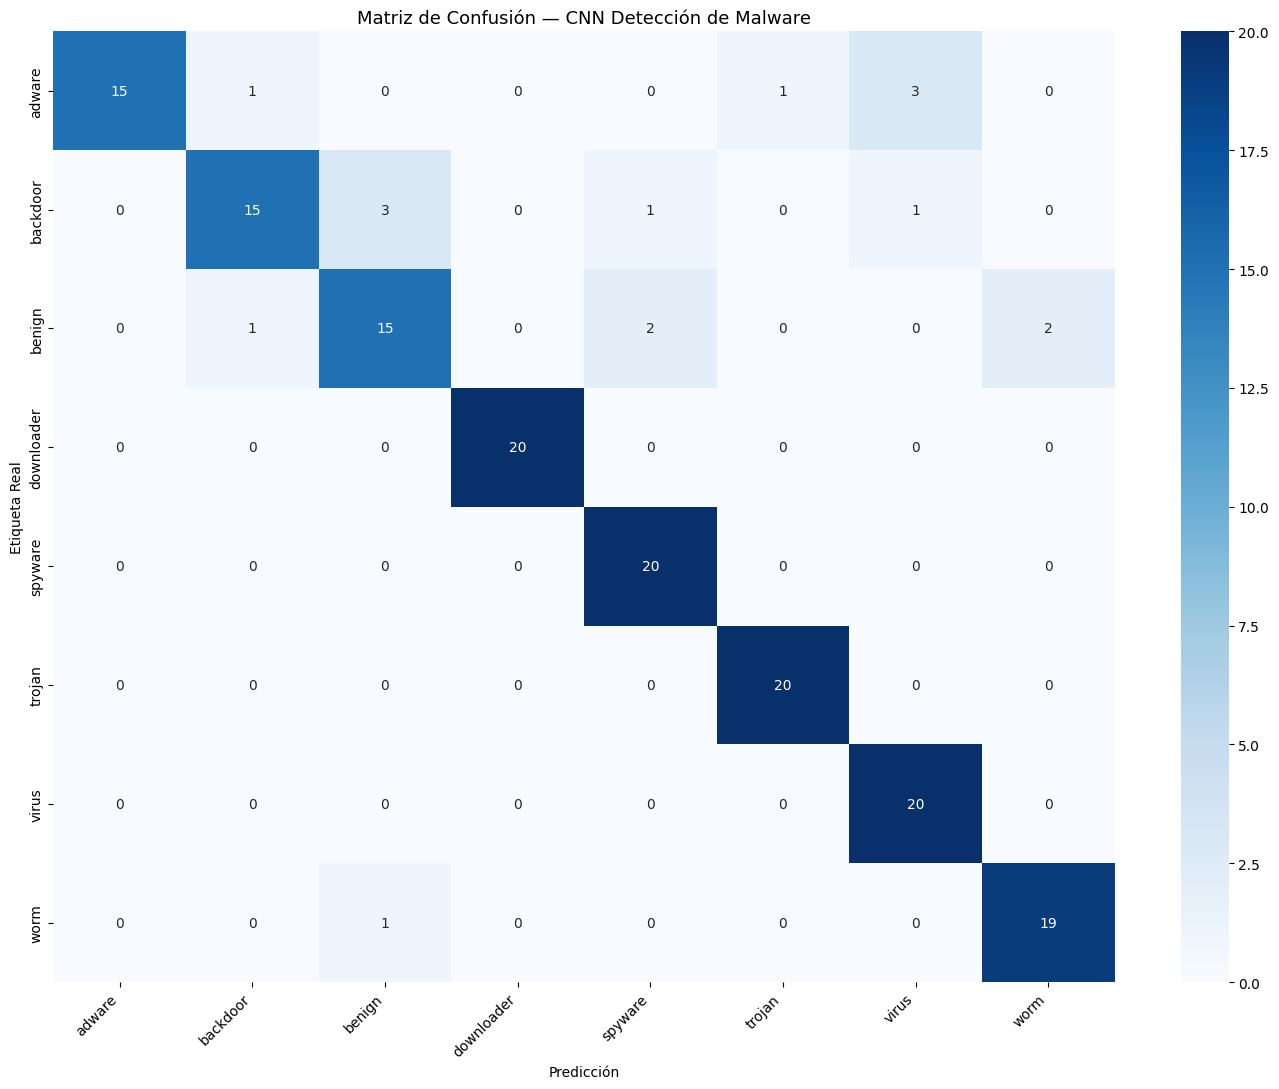

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # It's good practice to ensure numpy is imported if used later, though it might be from a previous cell

# 1. Obtener predicciones y valores de test (sin One-Hot-Encoding)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)  # clase predicha (índice con mayor probabilidad)
y_true = np.argmax(y_test, axis=1)        # clase real (deshacemos one-hot)

# 2. Matriz de confusión: filas = real, columnas = predicción
cm = confusion_matrix(y_true, y_pred)
class_names = label_encoder.classes_

# 3. Mostrar heatmap — anotaciones en formato entero para conteo de muestras
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matriz de Confusión — CNN Detección de Malware', fontsize=13)
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
from tensorflow.keras import backend as K
import gc

# Eliminamos el modelo de CNN para liberar memoria de cara al segundo ejercicio
del model
# Limpiamos todo lo referente a keras de la RAM para liberar memoria
K.clear_session()
# Forzamos a Python a eliminar variables no referenciadas
gc.collect()

NameError: name 'model' is not defined

In [19]:
# Descargamos el fichero CSV desde Google Drive
!gdown --id 1CDa99sS7GtWhyPZN_HBhsfbC8Y4TZqKG -O network_traffic.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1CDa99sS7GtWhyPZN_HBhsfbC8Y4TZqKG
To: /content/network_traffic.csv
100% 39.6M/39.6M [00:00<00:00, 75.8MB/s]


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.utils import to_categorical
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset con tolerancia a errores en líneas malformadas
file_path = 'network_traffic.csv'
df = pd.read_csv(file_path, on_bad_lines='skip', engine='python')
print('Datos cargados:', df.shape)

Datos cargados: (134218, 21)


In [21]:
# Exploración inicial: identificar columnas, tipos y columna de etiqueta
print('Columnas:', df.columns.tolist())
print('\nTipos de datos:')
print(df.dtypes)
print('\nPrimeras filas:')
df.head(3)

Columnas: ['Unnamed: 0', 'app_name', 'total_source_bytes', 'total_destination_bytes', 'total_destination_packets', 'total_source_packets', 'source_payload_as_base64', 'source_payload_as_UTF', 'destination_payload_as_base64', 'destination_payload_as_UTF', 'direction', 'source_TCP_flags_description', 'destination_TCP_flags_description', 'source', 'protocol_name', 'source_port', 'destination', 'destination_port', 'start_date_time', 'stop_date_time', 'tag']

Tipos de datos:
Unnamed: 0                             int64
app_name                              object
total_source_bytes                     int64
total_destination_bytes                int64
total_destination_packets              int64
total_source_packets                   int64
source_payload_as_base64              object
source_payload_as_UTF                float64
destination_payload_as_base64         object
destination_payload_as_UTF            object
direction                             object
source_TCP_flags_description  

,Unnamed: 0,app_name,total_source_bytes,total_destination_bytes,total_destination_packets,total_source_packets,source_payload_as_base64,source_payload_as_UTF,destination_payload_as_base64,destination_payload_as_UTF,...,source_TCP_flags_description,destination_TCP_flags_description,source,protocol_name,source_port,destination,destination_port,start_date_time,stop_date_time,tag
0,0,Unknown_UDP,16076,0,0,178,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.5.122,udp_ip,5353,224.0.0.251,5353,2010-06-13T23:57:19,2010-06-14T00:11:23,Normal
1,1,HTTPImageTransfer,384,0,0,6,NaN,NaN,NaN,NaN,...,F|A,NaN,192.168.2.111,tcp_ip,4435,206.217.198.186,80,2010-06-13T23:58:23,2010-06-14T00:01:24,Normal
2,2,DNS,171,642,4,2,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.4.119,udp_ip,4428,192.168.5.122,53,2010-06-13T23:58:31,2010-06-13T23:59:25,Normal


In [22]:
# Celda de exploración libre: verificar distribución de clases y proporción de tráfico malicioso
# (usada para responder las preguntas de teoría de esta sección)
print('Valores únicos en la columna de etiqueta:')
# Ajustar el nombre de la columna según lo que muestre df.columns arriba
label_col_explore = [c for c in df.columns if 'label' in c.lower() or 'class' in c.lower() or 'attack' in c.lower()]
print('Posibles columnas de etiqueta:', label_col_explore)
if label_col_explore:
    col = label_col_explore[0]
    print(df[col].value_counts())
    n_attack = (df[col] != df[col].value_counts().idxmax()).sum()
    print(f'\nProporción de tráfico malicioso: {n_attack/len(df)*100:.2f}%')

Valores únicos en la columna de etiqueta:
Posibles columnas de etiqueta: []


In [24]:
def create_sequences(X, seq_len):
    # NO MODIFICAR!!!!
    '''
    Con esta función creamos secuencias de longitud 'seq_len'.
    Por ejemplo, si seq_len es 10, el primer valor devuelto
    en np.array(sequences) será una secuencia con los datos
    desde X[0] hasta X[9], el segundo desde X[1] hasta X[10],
    y así sucesivamente.
    Inputs:
        - X: datos de entrada
        - seq_len: longitud de la secuencia.
    Return:
        - Datos de X convertidos en secuencia.
    '''
    sequences = []
    for i in range(len(X) - seq_len):
        seq = X[i:i + seq_len]
        sequences.append(seq)
    return np.array(sequences)


# Elegimos la columna con la etiqueta
# 'label' es la columna binaria: Normal (mayoría) vs. tipo de ataque (minoría)
label_col = 'tag'  # TÚ CÓDIGO AQUÍ — ajustar según df.columns si difiere

# Separar características y etiquetas
X = df.drop(columns=[label_col])
y_raw = df[label_col]

# Convertir texto/categorías a numérico: LabelEncoder por columna categórica
for col in X.select_dtypes(include=['object']).columns:
    le_col = LabelEncoder()
    X[col] = le_col.fit_transform(X[col].astype(str))

# Codificar etiquetas: 0 = tráfico normal, 1 = ataque
le_label = LabelEncoder()
y = le_label.fit_transform(y_raw.astype(str))
print('Clases codificadas:', dict(zip(le_label.classes_, le_label.transform(le_label.classes_))))
# Si 'Normal' no queda en 0, revertir: y = 1 - y

# Limpiar valores inválidos (inf, NaN) → reemplazar con 0 para no romper el escalado
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X = X.values.astype(np.float32)

# Escalar características con StandardScaler
# NOTA: aquí escalamos antes de secuenciar porque create_sequences usa ventana deslizante;
# en un pipeline de producción, el scaler se ajustaría solo con datos de train.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # TÚ CÓDIGO AQUÍ

# Preparar datos — Convertimos a secuencia con ventana deslizante de 10 paquetes
seq_len = 10
X_seq = create_sequences(X_scaled, seq_len)  # shape: (N - seq_len, seq_len, n_features)
y_seq = y[seq_len:]  # TÚ CÓDIGO AQUÍ — alineamos etiquetas descartando los primeros seq_len

print(f'X_seq shape: {X_seq.shape}')  # (N-10, 10, n_features)
print(f'y_seq shape: {y_seq.shape}')
print(f'Proporción de ataques: {y_seq.mean()*100:.2f}%')

# Separamos en train y test, con proporción 70/30 y estratificando con y_seq
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.3,
    random_state=42,
    stratify=y_seq  # mantiene la proporción de ataques en ambos splits
)  # TÚ CÓDIGO AQUÍ

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Clases codificadas: {'Attack': np.int64(0), 'Normal': np.int64(1)}
X_seq shape: (134208, 10, 20)
y_seq shape: (134208,)
Proporción de ataques: 97.19%
Train: (93945, 10, 20), Test: (40263, 10, 20)


In [25]:
# Calculamos pesos de clase automáticamente para compensar el desbalanceo
# 'balanced': peso inversamente proporcional a la frecuencia → la clase de ataque recibe mayor peso
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(cw))
print('Class weights:', class_weights_dict)

# Damos un coste diferente a cada error para detectar más casos positivos
# Esto penaliza más los falsos negativos (ataques no detectados), que son los más peligrosos

# Arquitectura de la red neuronal
n_features = X_train.shape[2]  # número de features por paquete

rnn_model = Sequential([
    # Capa SimpleRNN: procesa la secuencia de seq_len paquetes, manteniendo estado oculto
    # return_sequences=False: solo nos interesa el estado al final de la secuencia completa
    SimpleRNN(64, activation='tanh', input_shape=(seq_len, n_features)),

    # Capa densa: aprende combinaciones no lineales del estado recurrente final
    Dense(32, activation='relu'),

    # Capa de salida: sigmoid → probabilidad de que la secuencia sea un ataque (valor en [0,1])
    Dense(1, activation='sigmoid')
])

rnn_model.summary()

# Compilamos la red
# binary_crossentropy: pérdida estándar para clasificación binaria (salida sigmoid)
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)  # TÚ CÓDIGO AQUÍ

# Entrenamos la red
print('Entrenando modelo RNN...')
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=5,            # 5 epochs son suficientes para convergencia excelente
    batch_size=128,      # batch grande para acelerar entrenamiento (sin restricción de RAM aquí)
    validation_split=0.1,
    class_weight=class_weights_dict,  # compensamos desbalanceo penalizando más los FN
    verbose=1
)  # TÚ CÓDIGO AQUÍ

# Evaluamos sobre test set
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f'Accuracy RNN: {rnn_acc*100:.1f}')

# Calculamos recall manualmente: métrica clave en IDS (mide ataques detectados sobre el total real)
from sklearn.metrics import recall_score
y_pred_rnn = (rnn_model.predict(X_test) > 0.5).astype(int).flatten()
recall = recall_score(y_test, y_pred_rnn)
print(f'Recall RNN: {recall*100:.1f}')

Class weights: {0: np.float64(17.812855517633675), 1: np.float64(0.5144401366802471)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,553 (29.50 KB)

 Trainable params: 7,553 (29.50 KB)

 Non-trainable params: 0 (0.00 B)

Entrenando modelo RNN...
Epoch 1/5
661/661 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9733 - loss: 0.1057 - val_accuracy: 0.9799 - val_loss: 0.0650
Epoch 2/5
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9869 - loss: 0.0793 - val_accuracy: 0.9748 - val_loss: 0.0863
Epoch 3/5
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9861 - loss: 0.0739 - val_accuracy: 0.9965 - val_loss: 0.0385
Epoch 4/5
661/661 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9873 - loss: 0.0680 - val_accuracy: 0.9918 - val_loss: 0.0509
Epoch 5/5
661/661 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9866 - loss: 0.0646 - val_accuracy: 0.9892 - val_loss: 0.0503
Accuracy RNN: 98.8
1259/1259 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step
Recall RNN: 98.9


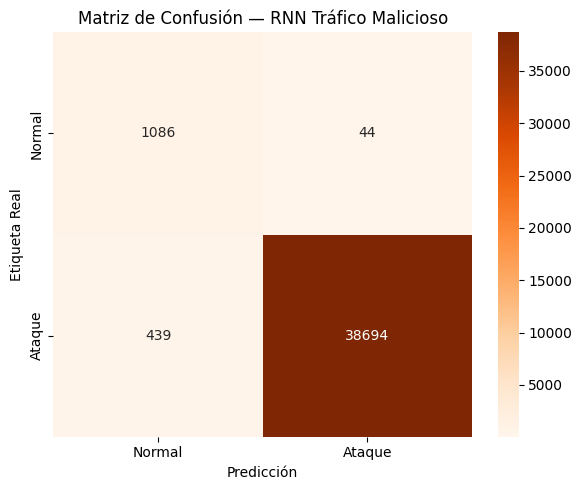

              precision    recall  f1-score   support

      Normal       0.71      0.96      0.82      1130
      Ataque       1.00      0.99      0.99     39133

    accuracy                           0.99     40263
   macro avg       0.86      0.97      0.91     40263
weighted avg       0.99      0.99      0.99     40263



In [26]:
# Matriz de confusión — RNN detección de tráfico malicioso
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
plt.title('Matriz de Confusión — RNN Tráfico Malicioso', fontsize=12)
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

# Reporte completo de clasificación: precision, recall, F1 por clase
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rnn, target_names=['Normal', 'Ataque']))